Proyecto M3 — Aprobación de Tarjeta de Crédito con LangGraph
Caso de negocio

Un cliente solicita una tarjeta de crédito mediante un canal digital.
El sistema debe:

recibir los datos,
validar identidad y documentos,
consultar listas de riesgo/fraude,
calcular score crediticio,
evaluar capacidad de pago,
decidir si:
se aprueba,
pasa a revisión manual,
o se rechaza.

In [1]:
%%capture
!pip install -q langgraph langchain langchain-openai typing_extensions pandas

In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from pprint import pprint
import uuid

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
# =====================================================
# ESTADO DEL SISTEMA
# =====================================================

class CreditCardState(TypedDict):

    solicitud_id: str
    cliente_nombre: str
    tipo_documento: str
    dni: str
    ingresos: float
    deuda_total: float
    score_crediticio: int
    resultado_listas: str
    capacidad_pago: float
    decision: str
    eventos: List[str]



In [4]:
# =====================================================
# NODO 1 - RECIBIR SOLICITUD
# =====================================================

def recibir_solicitud(state: CreditCardState):

    print("\n========== RECIBIENDO SOLICITUD ==========")

    state["eventos"].append(
        f"Solicitud recibida para {state['cliente_nombre']}"
    )

    return state

In [6]:
# =====================================================
# NODO 2 - VALIDAR DOCUMENTO
# =====================================================

def validar_documento(state: CreditCardState):

    print("\n========== VALIDANDO DOCUMENTO ==========")

    documento = state["dni"]

    # =====================================================
    # VALIDACIÓN DNI O CARNET DE EXTRANJERÍA
    # =====================================================

    # DNI:
    # 8 dígitos numéricos

    if len(documento) == 8 and documento.isdigit():

        tipo_documento = "DNI"

        print("DNI válido")

        state["eventos"].append(
            "DNI validado correctamente"
        )

    # CARNET DE EXTRANJERÍA:
    # entre 9 y 12 caracteres alfanuméricos

    elif 9 <= len(documento) <= 12 and documento.isalnum():

        tipo_documento = "CARNET_EXTRANJERIA"

        print("Carnet de extranjería válido")

        state["eventos"].append(
            "Carnet de extranjería validado correctamente"
        )

    else:

        tipo_documento = "INVALIDO"

        print("Documento inválido")

        state["decision"] = "RECHAZADO"

        state["eventos"].append(
            "Documento inválido"
        )

    # Guardar tipo detectado

    state["tipo_documento"] = tipo_documento

    return state


In [7]:
# =====================================================
# NODO 3 - REVISAR LISTAS
# =====================================================

def revisar_listas(state: CreditCardState):

    print("\n========== REVISANDO LISTAS ==========")

    documento = state["dni"]

    # Simulación simple de listas de riesgo

    if documento.startswith("0"):

        resultado = "ALTO_RIESGO"

    else:

        resultado = "SIN_ALERTAS"

    state["resultado_listas"] = resultado

    state["eventos"].append(
        f"Resultado listas: {resultado}"
    )

    print(f"Resultado listas: {resultado}")

    return state

In [8]:
# =====================================================
# NODO 4 - CALCULAR RIESGO
# =====================================================

def calcular_riesgo(state: CreditCardState):

    print("\n========== CALCULANDO RIESGO ==========")

    ingresos = state["ingresos"]

    deuda = state["deuda_total"]

    capacidad_pago = ingresos - deuda

    state["capacidad_pago"] = capacidad_pago

    print(f"Ingresos: {ingresos}")

    print(f"Deuda total: {deuda}")

    print(f"Capacidad de pago: {capacidad_pago}")

    # =====================================================
    # SCORE SIMULADO
    # =====================================================

    if capacidad_pago >= 3000:

        score = 85

    elif capacidad_pago >= 1500:

        score = 65

    else:

        score = 40

    state["score_crediticio"] = score

    state["eventos"].append(
        f"Score calculado: {score}"
    )

    print(f"Score final: {score}")

    return state




In [9]:
# =====================================================
# NODO 5 - TOMAR DECISIÓN
# =====================================================

def tomar_decision(state: CreditCardState):

    print("\n========== TOMANDO DECISIÓN ==========")

    score = state["score_crediticio"]

    listas = state["resultado_listas"]

    # =====================================================
    # REGLAS DE NEGOCIO
    # =====================================================

    if listas == "ALTO_RIESGO":

        decision = "RECHAZADO"

    elif score >= 80:

        decision = "APROBADO"

    elif score >= 60:

        decision = "REVISION_MANUAL"

    else:

        decision = "RECHAZADO"

    state["decision"] = decision

    state["eventos"].append(
        f"Decisión final: {decision}"
    )

    print(f"Decisión final: {decision}")

    return state


In [10]:
# =====================================================
# CREACIÓN DEL GRAFO
# =====================================================

workflow = StateGraph(CreditCardState)


In [11]:
# =====================================================
# AGREGAR NODOS
# =====================================================


workflow.add_node(
    "recibir_solicitud",
    recibir_solicitud
)

workflow.add_node(
    "validar_documento",
    validar_documento
)

workflow.add_node(
    "revisar_listas",
    revisar_listas
)

workflow.add_node(
    "calcular_riesgo",
    calcular_riesgo
)

workflow.add_node(
    "tomar_decision",
    tomar_decision
)

In [36]:
card_graph = workflow.compile()

In [12]:
# =====================================================
# PUNTO DE ENTRADA
# =====================================================

workflow.set_entry_point(
    "recibir_solicitud"
)




In [13]:
# =====================================================
# CONEXIONES DEL GRAFO
# =====================================================

workflow.add_edge(
    "recibir_solicitud",
    "validar_documento"
)

workflow.add_edge(
    "validar_documento",
    "revisar_listas"
)

workflow.add_edge(
    "revisar_listas",
    "calcular_riesgo"
)

workflow.add_edge(
    "calcular_riesgo",
    "tomar_decision"
)

workflow.add_edge(
    "tomar_decision",
    END
)




In [14]:
# =====================================================
# CHECKPOINTER
# =====================================================

memory = InMemorySaver()

In [15]:
# =====================================================
# COMPILAR GRAFO
# =====================================================

app = workflow.compile(
    checkpointer=memory
)

In [16]:
# =====================================================
# THREAD ID
# =====================================================

thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "thread_id": thread_id
    }
}


In [20]:
# =====================================================
# ESTADO INICIAL
# =====================================================

# Simulamos error OCR:
# El sistema leyó 7500 en vez de 10000

initial_state = {

    "solicitud_id": "SOL-001",

    "cliente_nombre": "Andrea Coronado",

    "tipo_documento": "",

    "dni": "12345678",

    "ingresos": 7500,

    "deuda_total": 800,

    "score_crediticio": 0,

    "resultado_listas": "",

    "capacidad_pago": 0,

    "decision": "",

    "eventos": []
}


In [21]:
# =====================================================
# EJECUCIÓN ORIGINAL
# =====================================================

print("\n\n========== FLUJO ORIGINAL ==========")

resultado_original = app.invoke(
    initial_state,
    config=config
)



========== FLUJO ORIGINAL ==========

========== RECIBIENDO SOLICITUD ==========

========== VALIDANDO DOCUMENTO ==========
DNI válido

========== REVISANDO LISTAS ==========
Resultado listas: SIN_ALERTAS

========== CALCULANDO RIESGO ==========
Ingresos: 7500
Deuda total: 800
Capacidad de pago: 6700
Score final: 85

========== TOMANDO DECISIÓN ==========
Decisión final: APROBADO


In [22]:

# =====================================================
# RESULTADO ORIGINAL
# =====================================================

print("\n========== RESULTADO ORIGINAL ==========")

pprint(resultado_original)


========== RESULTADO ORIGINAL ==========
{'capacidad_pago': 6700,
 'cliente_nombre': 'Andrea Coronado',
 'decision': 'APROBADO',
 'deuda_total': 800,
 'dni': '12345678',
 'eventos': ['Solicitud recibida para Andrea Coronado',
             'DNI validado correctamente',
             'Resultado listas: SIN_ALERTAS',
             'Score calculado: 85',
             'Decisión final: APROBADO'],
 'ingresos': 7500,
 'resultado_listas': 'SIN_ALERTAS',
 'score_crediticio': 85,
 'solicitud_id': 'SOL-001',
 'tipo_documento': 'DNI'}


In [23]:
# =====================================================
# HISTORIAL DE SNAPSHOTS / CHECKPOINTS
# =====================================================

print("\n========== SNAPSHOTS ==========")

history = list(
    app.get_state_history(config)
)

for i, snapshot in enumerate(history):

    print(f"\nSnapshot {i+1}")

    pprint(snapshot.values)



========== SNAPSHOTS ==========

Snapshot 1
{'capacidad_pago': 6700,
 'cliente_nombre': 'Andrea Coronado',
 'decision': 'APROBADO',
 'deuda_total': 800,
 'dni': '12345678',
 'eventos': ['Solicitud recibida para Andrea Coronado',
             'DNI validado correctamente',
             'Resultado listas: SIN_ALERTAS',
             'Score calculado: 85',
             'Decisión final: APROBADO'],
 'ingresos': 7500,
 'resultado_listas': 'SIN_ALERTAS',
 'score_crediticio': 85,
 'solicitud_id': 'SOL-001',
 'tipo_documento': 'DNI'}

Snapshot 2
{'capacidad_pago': 6700,
 'cliente_nombre': 'Andrea Coronado',
 'decision': '',
 'deuda_total': 800,
 'dni': '12345678',
 'eventos': ['Solicitud recibida para Andrea Coronado',
             'DNI validado correctamente',
             'Resultado listas: SIN_ALERTAS',
             'Score calculado: 85',
             'Decisión final: APROBADO'],
 'ingresos': 7500,
 'resultado_listas': 'SIN_ALERTAS',
 'score_crediticio': 85,
 'solicitud_id': 'SOL-001',
 'tip

In [24]:
# =====================================================
# FORK DEL FLUJO
# =====================================================

print("\n\n========== FORK ==========")

print("Corrigiendo ingresos de 7500 -> 10000")

# Nueva rama del flujo

fork_state = resultado_original.copy()

fork_state["ingresos"] = 10000

fork_state["eventos"].append(
    "Corrección manual de ingresos"
)




========== FORK ==========
Corrigiendo ingresos de 7500 -> 10000


In [25]:
# =====================================================
# RE-EJECUCIÓN
# =====================================================

resultado_fork = app.invoke(
    fork_state,
    config=config
)


========== RECIBIENDO SOLICITUD ==========

========== VALIDANDO DOCUMENTO ==========
DNI válido

========== REVISANDO LISTAS ==========
Resultado listas: SIN_ALERTAS

========== CALCULANDO RIESGO ==========
Ingresos: 10000
Deuda total: 800
Capacidad de pago: 9200
Score final: 85

========== TOMANDO DECISIÓN ==========
Decisión final: APROBADO


In [26]:
# =====================================================
# RESULTADO NUEVA RAMA
# =====================================================

print("\n========== RESULTADO FORK ==========")

pprint(resultado_fork)


========== RESULTADO FORK ==========
{'capacidad_pago': 9200,
 'cliente_nombre': 'Andrea Coronado',
 'decision': 'APROBADO',
 'deuda_total': 800,
 'dni': '12345678',
 'eventos': ['Solicitud recibida para Andrea Coronado',
             'DNI validado correctamente',
             'Resultado listas: SIN_ALERTAS',
             'Score calculado: 85',
             'Decisión final: APROBADO',
             'Corrección manual de ingresos',
             'Solicitud recibida para Andrea Coronado',
             'DNI validado correctamente',
             'Resultado listas: SIN_ALERTAS',
             'Score calculado: 85',
             'Decisión final: APROBADO'],
 'ingresos': 10000,
 'resultado_listas': 'SIN_ALERTAS',
 'score_crediticio': 85,
 'solicitud_id': 'SOL-001',
 'tipo_documento': 'DNI'}


In [27]:
# =====================================================
# TRAZABILIDAD
# =====================================================

print("\n========== EVENTOS ==========")

for evento in resultado_fork["eventos"]:

    print("-", evento)



========== EVENTOS ==========
- Solicitud recibida para Andrea Coronado
- DNI validado correctamente
- Resultado listas: SIN_ALERTAS
- Score calculado: 85
- Decisión final: APROBADO
- Corrección manual de ingresos
- Solicitud recibida para Andrea Coronado
- DNI validado correctamente
- Resultado listas: SIN_ALERTAS
- Score calculado: 85
- Decisión final: APROBADO


In [28]:
# =====================================================
# RESULTADO FINAL
# =====================================================

print("\n========== DECISIÓN FINAL ==========")

print(
    resultado_fork["decision"]
)


========== DECISIÓN FINAL ==========
APROBADO


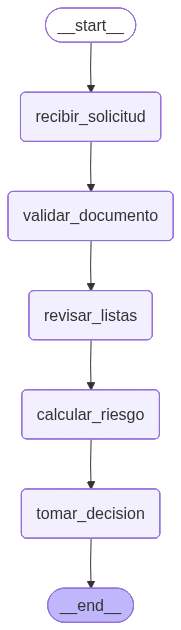

In [30]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [31]:
print(
    app.get_graph().draw_mermaid()
)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	recibir_solicitud(recibir_solicitud)
	validar_documento(validar_documento)
	revisar_listas(revisar_listas)
	calcular_riesgo(calcular_riesgo)
	tomar_decision(tomar_decision)
	__end__([<p>__end__</p>]):::last
	__start__ --> recibir_solicitud;
	calcular_riesgo --> tomar_decision;
	recibir_solicitud --> validar_documento;
	revisar_listas --> calcular_riesgo;
	validar_documento --> revisar_listas;
	tomar_decision --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [34]:
# =====================================================
# VISUALIZACIÓN DEL GRAFO
# =====================================================
graph_png = app.get_graph().draw_mermaid_png()

with open("grafo.png", "wb") as f:
    f.write(graph_png)